In [1]:
import joblib
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

In [2]:
df = pd.read_csv("../data/processed/loans_feature_engineered.csv")
df.head()

,loan_amnt,term,int_rate,grade,annual_inc,dti,delinq_2yrs,inq_last_6mths,open_acc,pub_rec,...,purpose_credit_card,purpose_debt_consolidation,purpose_home_improvement,purpose_house,purpose_major_purchase,purpose_medical,purpose_moving,purpose_other,purpose_small_business,purpose_vacation
0,0.078481,0,0.338006,2,0.000500,0.00691,0.000000,0.030303,0.069307,0.0,...,False,True,False,False,False,False,False,False,False,False
1,0.612658,0,0.260125,2,0.000591,0.01706,0.017241,0.121212,0.217822,0.0,...,False,False,False,False,False,False,False,False,True,False
2,0.493671,1,0.213006,1,0.000573,0.01178,0.000000,0.000000,0.059406,0.0,...,False,False,True,False,False,False,False,False,False,False
3,0.873418,1,0.371495,2,0.001000,0.01806,0.000000,0.000000,0.128713,0.0,...,False,True,False,False,False,False,False,False,False,False
4,0.250633,1,0.667445,5,0.000949,0.02637,0.017241,0.090909,0.118812,0.0,...,False,False,False,False,True,False,False,False,False,False


In [3]:
X = df.drop(columns=['int_rate'])
y = df['int_rate']

In [4]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [5]:
metrics_df = pd.DataFrame(columns=["Model", "R2", "MSE"])

# Linear Regression

In [6]:
linear_model = LinearRegression()
linear_model.fit(X_train, y_train)
y_pred = linear_model.predict(X_test)
linear_mse = mean_squared_error(y_test, y_pred)
linear_r2 = r2_score(y_test, y_pred)
print(f"Mean Squared Error: {linear_mse}")
print(f"R^2 Score: {linear_r2}")
new_row = pd.DataFrame([{"Model": "Linear", "R2": linear_r2, "MSE": linear_mse}])
metrics_df = pd.concat([metrics_df, new_row], ignore_index=True)
joblib.dump(linear_model, "../saved_models/linear_model.joblib")

Mean Squared Error: 0.0031365492371775916
R^2 Score: 0.9112183394779777


C:\Users\Girish\AppData\Local\Temp\ipykernel_32600\4022629412.py:9: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  metrics_df = pd.concat([metrics_df, new_row], ignore_index=True)


['../saved_models/linear_model.joblib']

# Decision Tree Regression

In [7]:
dtree_model = DecisionTreeRegressor(random_state=42)
dtree_model.fit(X_train, y_train)
y_pred = dtree_model.predict(X_test)
dtree_mse = mean_squared_error(y_test, y_pred)
dtree_r2 = r2_score(y_test, y_pred)
print(f"Mean Squared Error: {dtree_mse}")
print(f"R^2 Score: {dtree_r2}")
new_row = pd.DataFrame([{"Model": "Decision Tree", "R2": dtree_r2, "MSE": dtree_mse}])
metrics_df = pd.concat([metrics_df, new_row], ignore_index=True)
joblib.dump(dtree_model, "../saved_models/dtree_model.joblib")

Mean Squared Error: 0.004997104676508864
R^2 Score: 0.8585543482868971


['../saved_models/dtree_model.joblib']

# Random Forest Regression

In [8]:
rf_model = RandomForestRegressor(n_estimators=50, max_depth=10, n_jobs=-1, random_state=42)
rf_model.fit(X_train, y_train)
y_pred = rf_model.predict(X_test)
rf_mse = mean_squared_error(y_test, y_pred)
rf_r2 = r2_score(y_test, y_pred)
print(f"Mean Squared Error: {rf_mse}")
print(f"R^2 Score: {rf_r2}")
new_row = pd.DataFrame([{"Model": "Random Forest", "R2": rf_r2, "MSE": rf_mse}])
metrics_df = pd.concat([metrics_df, new_row], ignore_index=True)
joblib.dump(rf_model, "../saved_models/rf_model.joblib")

Mean Squared Error: 0.002511694510862594
R^2 Score: 0.9289051780997744


['../saved_models/rf_model.joblib']

# Gradient Boost Regression

In [9]:
gbr_model = GradientBoostingRegressor(n_estimators=100, random_state=42)
gbr_model.fit(X_train, y_train)
y_pred = gbr_model.predict(X_test)
gbr_mse = mean_squared_error(y_test, y_pred)
gbr_r2 = r2_score(y_test, y_pred)
print(f"Mean Squared Error: {gbr_mse}")
print(f"R^2 Score: {gbr_r2}")
new_row = pd.DataFrame([{"Model": "Gradient Boosting", "R2": gbr_r2, "MSE": gbr_mse}])
metrics_df = pd.concat([metrics_df, new_row], ignore_index=True)
joblib.dump(gbr_model, "../saved_models/gbr_model.joblib")

Mean Squared Error: 0.002575713601645752
R^2 Score: 0.9270930843766886


['../saved_models/gbr_model.joblib']

# Comparative Analysis

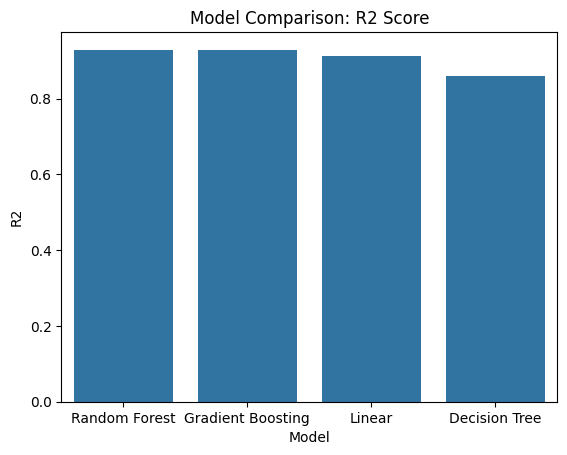

In [12]:
# R2 comparison
metrics_df = metrics_df.sort_values(by="R2", ascending=False)
sns.barplot(x="Model", y="R2", data=metrics_df)
plt.title("Model Comparison: R2 Score")
plt.show()

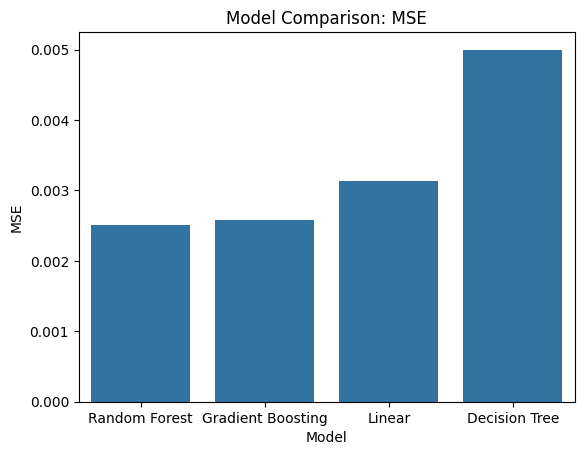

In [13]:
# MSE comparison
metrics_df = metrics_df.sort_values(by="MSE")
sns.barplot(x="Model", y="MSE", data=metrics_df)
plt.title("Model Comparison: MSE")
plt.show()
